# Problemática
¿Cómo influyen los puntos de interés urbanos en la variabilidad del precio y la demanda de alojamientos Airbnb en NYC, y cómo puede una empresa utilizar esta información para maximizar ingresos?

# **Cargar Dataset Base (Airbnb Kaggle)**


In [ ]:
import pandas as pd

# Cargar dataset
df_airbnb = pd.read_csv('/content/AB_NYC_2019.csv')

In [ ]:

# Mostrar las primeras 5 líneas
df_airbnb.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


# **Limpieza inicial: valores nulos, duplicados, formatos.**

In [ ]:
import pandas as pd

# 1. Cargar dataset
df_airbnb = pd.read_csv("AB_NYC_2019.csv")

# Eliminar columnas innecesarias para la investigación
df_airbnb = df_airbnb.drop(columns=[
    'id',
    'host_id',
    'host_name',
    'last_review'
])

print("\n🔹 Info general:")
print(df_airbnb.info())

# -----------------------------------
# 2. VALORES NULOS
# -----------------------------------

# name → texto
df_airbnb['name'] = df_airbnb['name'].fillna("Unknown")

# reviews_per_month → numérico
df_airbnb['reviews_per_month'] = df_airbnb['reviews_per_month'].fillna(0)

# -----------------------------------
# 3. DUPLICADOS
# -----------------------------------

df_airbnb = df_airbnb.drop_duplicates()

# -----------------------------------
# 4. FORMATOS (TIPOS DE DATOS)
# -----------------------------------

# Asegurar tipos correctos
df_airbnb['price'] = pd.to_numeric(df_airbnb['price'], errors='coerce')
df_airbnb['minimum_nights'] = pd.to_numeric(df_airbnb['minimum_nights'], errors='coerce')
df_airbnb['number_of_reviews'] = pd.to_numeric(df_airbnb['number_of_reviews'], errors='coerce')

# -----------------------------------
# 5. LIMPIEZA DE ABSURDOS
# -----------------------------------

# Eliminar precios absurdos
df_airbnb = df_airbnb[df_airbnb['price'] > 0]

# Eliminar noches mínimas absurdas
df_airbnb = df_airbnb[df_airbnb['minimum_nights'] <= 365]

# Resetear índices
df_airbnb = df_airbnb.reset_index(drop=True)

# -----------------------------------
# 6. RESULTADO FINAL
# -----------------------------------
print("\n🔹 Dataset limpio:")
print(df_airbnb.head())

print("\n🔹 Dimensiones finales:", df_airbnb.shape)


🔹 Info general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  object 
 1   neighbourhood_group             48895 non-null  object 
 2   neighbourhood                   48895 non-null  object 
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  object 
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   reviews_per_month               38843 non-null  float64
 10  calculated_host_listings_count  48895 non-null  int64  
 11  availability_365                48895 non-null  int64  
dtypes: float64(3), 

# **Cargar Dataset Base (Inside Airbnb)**

In [ ]:
import pandas as pd

# Cargar dataset
df_insideairbnb = pd.read_csv("listings.csv")

# -----------------------------
# Vista general
# -----------------------------
print("\nDimensiones del dataset:")
print(df_insideairbnb.shape)

print("\nInformación general:")
print(df_insideairbnb.info())


Dimensiones del dataset:
(36445, 85)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36445 entries, 0 to 36444
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36445 non-null  int64  
 1   listing_url                                   36445 non-null  object 
 2   scrape_id                                     36445 non-null  int64  
 3   last_scraped                                  36445 non-null  object 
 4   source                                        36445 non-null  object 
 5   name                                          36443 non-null  object 
 6   description                                   34952 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   36445 non-null  object 
 9   h

# **Limpieza inicial: valores nulos, duplicados, formatos.**

In [ ]:
columnas_relevantes = [
    'id',
    'neighbourhood_cleansed',
    'neighbourhood_group_cleansed',
    'latitude',
    'longitude',
    'number_of_reviews',
    'availability_365',
    'minimum_nights',
    'review_scores_rating',
    'review_scores_location',
    'review_scores_value'
]

df_insideairbnb_columnas_relevantes = df_insideairbnb[columnas_relevantes]

print("Columnas después de selección:")
print(df_insideairbnb_columnas_relevantes.columns)

Columnas después de selección:
Index(['id', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
       'latitude', 'longitude', 'number_of_reviews', 'availability_365',
       'minimum_nights', 'review_scores_rating', 'review_scores_location',
       'review_scores_value'],
      dtype='object')


In [ ]:
# -----------------------------
# Valores nulos
# -----------------------------
print("\nValores nulos por columna:")
print(df_insideairbnb_columnas_relevantes.isnull().sum())

# -----------------------------
# Duplicados
# -----------------------------
print("\nNúmero de filas duplicadas:")
print(df_insideairbnb_columnas_relevantes.duplicated().sum())

# -----------------------------
# Tipos de datos
# -----------------------------
print("\nTipos de datos:")
print(df_insideairbnb_columnas_relevantes.dtypes)


Valores nulos por columna:
id                                  0
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
latitude                            0
longitude                           0
number_of_reviews                   0
availability_365                    0
minimum_nights                     27
review_scores_rating            11496
review_scores_location          11513
review_scores_value             11512
dtype: int64

Número de filas duplicadas:
0

Tipos de datos:
id                                int64
neighbourhood_cleansed           object
neighbourhood_group_cleansed     object
latitude                        float64
longitude                       float64
number_of_reviews                 int64
availability_365                  int64
minimum_nights                  float64
review_scores_rating            float64
review_scores_location          float64
review_scores_value             float64
dtype: object


In [ ]:
# -----------------------------
# 1. Eliminar duplicados
# -----------------------------
df_insideairbnb_columnas_relevantes = df_insideairbnb_columnas_relevantes.drop_duplicates()

# -----------------------------
# 2. Manejo de valores nulos
# -----------------------------

# Ubicación (crítico)
df_insideairbnb_columnas_relevantes = df_insideairbnb_columnas_relevantes.dropna(subset=['latitude', 'longitude'])

# Reviews → NaN = sin reseñas
df_insideairbnb_columnas_relevantes['number_of_reviews'] = df_insideairbnb_columnas_relevantes['number_of_reviews'].fillna(0)

# Availability → NaN = no disponible
df_insideairbnb_columnas_relevantes['availability_365'] = df_insideairbnb_columnas_relevantes['availability_365'].fillna(0)

# Minimum nights → imputar con mediana (evita error de conversión)
df_insideairbnb_columnas_relevantes['minimum_nights'] = df_insideairbnb_columnas_relevantes['minimum_nights'].fillna(df_insideairbnb_columnas_relevantes['minimum_nights'].median())

# Scores → NaN = sin reviews (NO eliminar filas)
df_insideairbnb_columnas_relevantes['review_scores_rating'] = df_insideairbnb_columnas_relevantes['review_scores_rating'].fillna(0)
df_insideairbnb_columnas_relevantes['review_scores_location'] = df_insideairbnb_columnas_relevantes['review_scores_location'].fillna(0)
df_insideairbnb_columnas_relevantes['review_scores_value'] = df_insideairbnb_columnas_relevantes['review_scores_value'].fillna(0)

# -----------------------------
# 3. Estandarización de texto
# -----------------------------
df_insideairbnb_columnas_relevantes['neighbourhood_cleansed'] = df_insideairbnb_columnas_relevantes['neighbourhood_cleansed'].str.lower().str.strip()
df_insideairbnb_columnas_relevantes['neighbourhood_group_cleansed'] = df_insideairbnb_columnas_relevantes['neighbourhood_group_cleansed'].str.lower().str.strip()

# -----------------------------
# 4. Tipos de datos
# -----------------------------
df_insideairbnb_columnas_relevantes['minimum_nights'] = df_insideairbnb_columnas_relevantes['minimum_nights'].astype(int)

# **Resumen del proceso de limpieza de datos**

Se realizó un proceso de limpieza orientado a preservar la mayor cantidad de información relevante para el análisis de demanda, ubicación y percepción de los alojamientos.

En primer lugar, se eliminaron los registros duplicados para evitar sesgos en los resultados. Posteriormente, se trataron los valores nulos considerando la importancia de cada variable. Las columnas de latitud y longitud, al ser esenciales para el análisis geográfico, fueron depuradas eliminando únicamente los registros sin esta información.

En el caso de variables relacionadas con la demanda, como number_of_reviews y availability_365, los valores nulos fueron reemplazados por 0, interpretándose como ausencia de reseñas o disponibilidad. Para minimum_nights, los valores faltantes se imputaron utilizando la mediana, con el fin de mantener la distribución de los datos y evitar distorsiones.

Respecto a las variables de percepción (review_scores_*), los valores nulos fueron tratados como alojamientos sin reseñas, asignándoles el valor 0. Esta decisión permitió conservar un volumen significativo de datos sin introducir sesgos por eliminación masiva de registros.

Finalmente, se estandarizaron las variables de texto relacionadas con la ubicación para asegurar consistencia en el análisis, y se corrigieron los tipos de datos para facilitar su procesamiento.

Como resultado, se obtuvo un dataset limpio, consistente y adecuado para analizar la relación entre ubicación, demanda y percepción de los alojamientos en Airbnb.

In [ ]:
# -----------------------------
# Resultado final
# -----------------------------
print("\nValores nulos después de limpieza:")
print(df_insideairbnb_columnas_relevantes.isnull().sum())

print("\nInfo final:")
print(df_insideairbnb_columnas_relevantes.info())

print("\nDataset limpio:")
print(df_insideairbnb_columnas_relevantes.head())

print("\nDimensiones finales:")
print(df_insideairbnb_columnas_relevantes.shape)


Valores nulos después de limpieza:
id                              0
neighbourhood_cleansed          0
neighbourhood_group_cleansed    0
latitude                        0
longitude                       0
number_of_reviews               0
availability_365                0
minimum_nights                  0
review_scores_rating            0
review_scores_location          0
review_scores_value             0
dtype: int64

Info final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36445 entries, 0 to 36444
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            36445 non-null  int64  
 1   neighbourhood_cleansed        36445 non-null  object 
 2   neighbourhood_group_cleansed  36445 non-null  object 
 3   latitude                      36445 non-null  float64
 4   longitude                     36445 non-null  float64
 5   number_of_reviews             36445 n

EDA Inicial

### **Análisis de Distribución de Precios**

Identificar variaciones de costo según la ubicación geográfica (Ciudad).

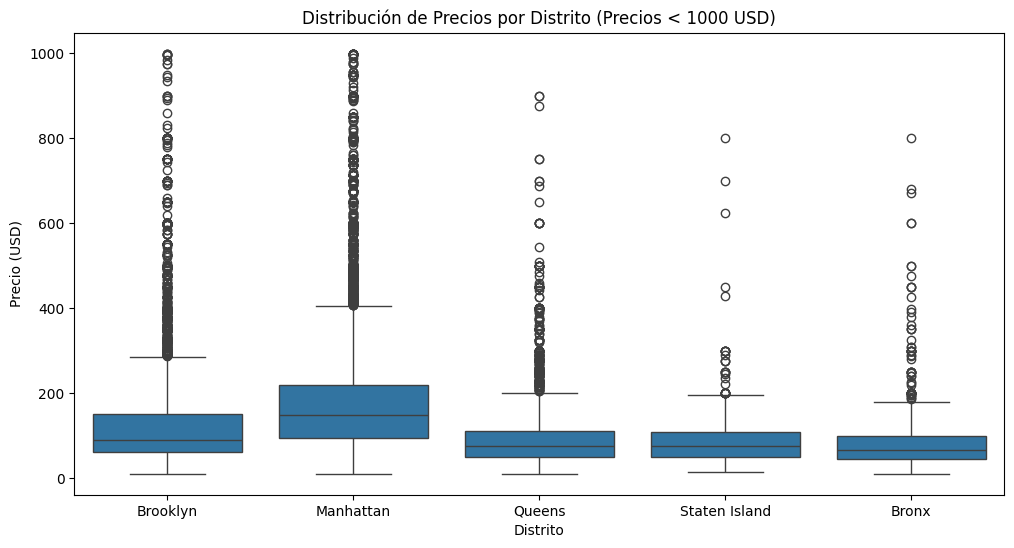

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='neighbourhood_group', y='price', data=df_airbnb[df_airbnb['price'] < 1000])
plt.title('Distribución de Precios por Distrito (Precios < 1000 USD)')
plt.xlabel('Distrito')
plt.ylabel('Precio (USD)')
plt.show()

Manhattan presenta la mediana de precios más alta y la mayor cantidad de valores atípicos de lujo. Brooklyn le sigue de cerca, mientras que el Bronx y Staten Island ofrecen las opciones más económicas.

### **Análisis de Demanda Acumulada**
Medir el volumen de actividad turística a través del número total de reseñas.

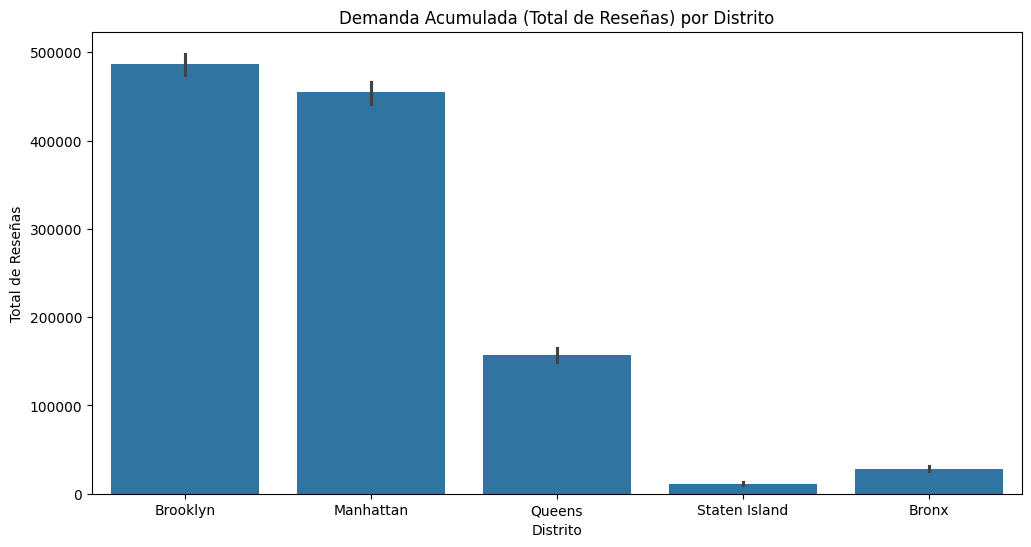

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='neighbourhood_group', y='number_of_reviews', data=df_airbnb, estimator=sum)
plt.title('Demanda Acumulada (Total de Reseñas) por Distrito')
plt.xlabel('Distrito')
plt.ylabel('Total de Reseñas')
plt.show()

Brooklyn y Manhattan dominan la demanda. Esto sugiere que los puntos de interés urbanos en estas áreas generan un flujo constante de huéspedes, validando su importancia para la generación de ingresos.

### **Mapa de Calor de Precios**

Explorar geográficamente dónde se concentran los precios más altos y cómo se correlacionan las métricas de calidad de la ubicación con la demanda.

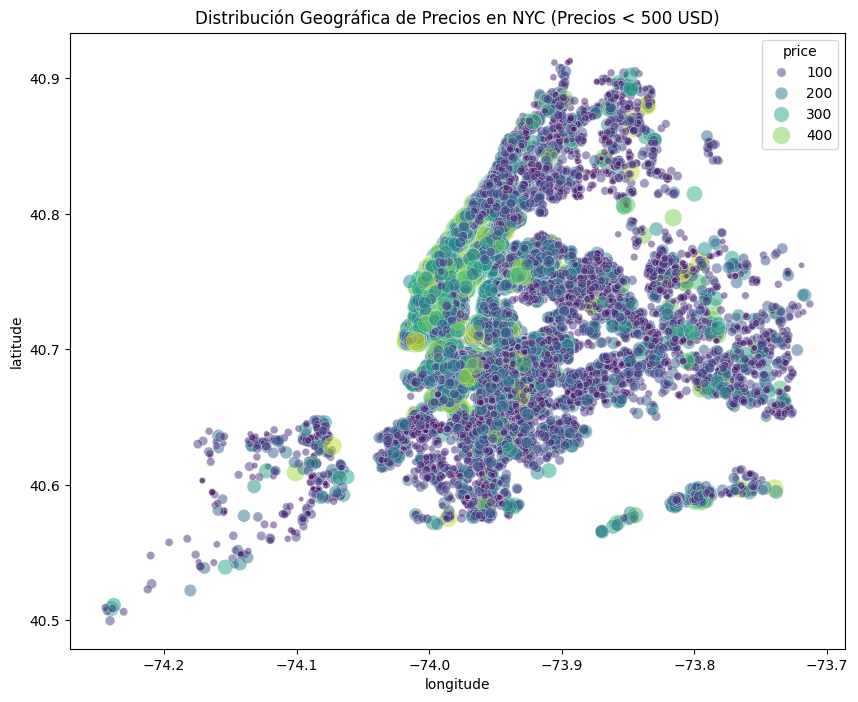

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='price', size='price',
                data=df_airbnb[df_airbnb['price'] < 500], palette='viridis', alpha=0.5, sizes=(10, 200))
plt.title('Distribución Geográfica de Precios en NYC (Precios < 500 USD)')
plt.show()

Se observa una alta densidad de puntos verdes (precios caros) concentrados en el Lower Manhattan y áreas de Brooklyn adyacentes al East River (Williamsburg/DUMBO), coincidiendo con las zonas de mayor atractivo turístico y conectividad.

# Matriz de Correlación

Entender la relación estadística entre la ubicación, la calificación y la disponibilidad.

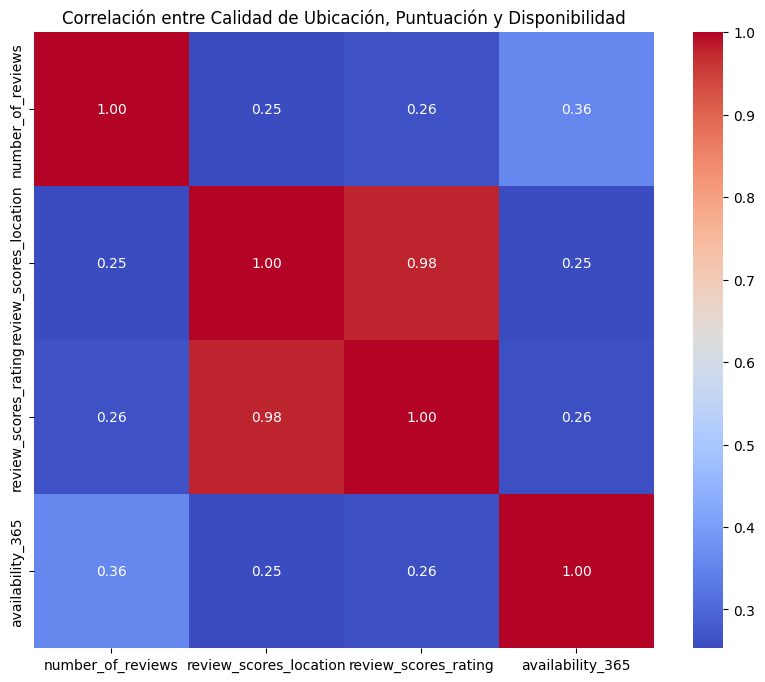

In [ ]:
plt.figure(figsize=(10, 8))
corr = df_insideairbnb_columnas_relevantes[['price' if 'price' in df_insideairbnb_columnas_relevantes else 'number_of_reviews',
                                            'review_scores_location', 'review_scores_rating', 'availability_365']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Calidad de Ubicación, Puntuación y Disponibilidad')
plt.show()

Existe una correlación positiva moderada entre la puntuación de ubicación (review_scores_location) y la calificación general. Sin embargo, la correlación entre precio y reseñas es baja, lo que indica que la demanda no depende solo del precio, sino de la experiencia de ubicación.

### **Análisis de Disponibilidad vs. Demanda por Tipo de Habitación**
Identificar si existe un patrón entre cuántos días al año está disponible un alojamiento y su volumen de reseñas, segmentado por el tipo de propiedad.

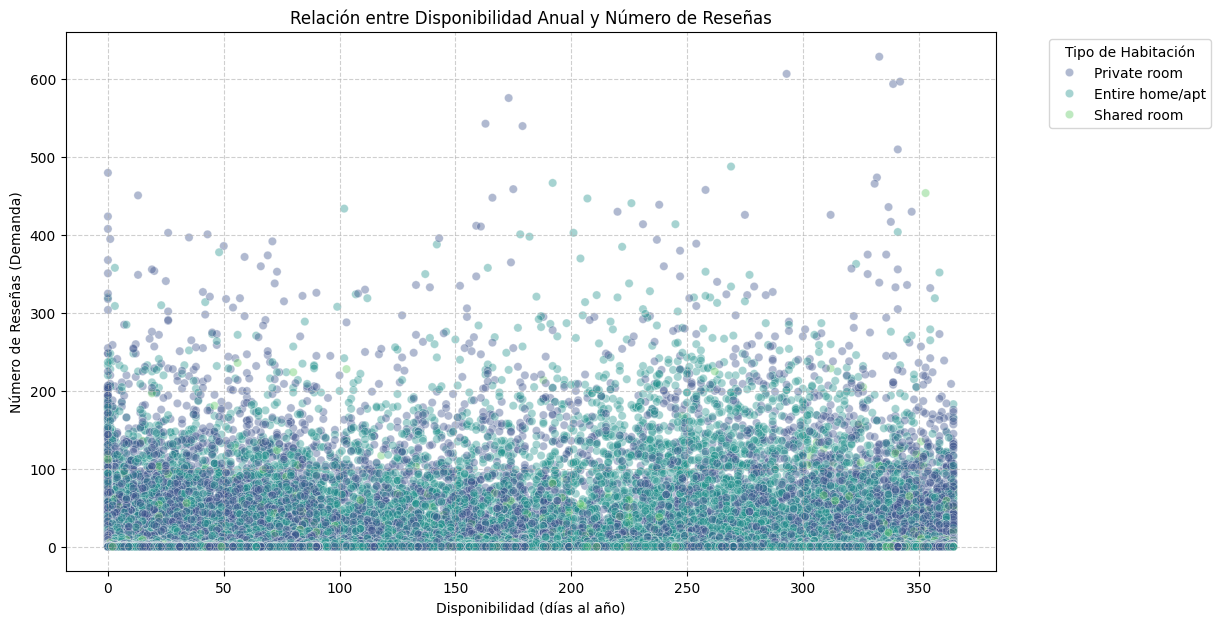

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos el dataset de Inside Airbnb para este análisis
plt.figure(figsize=(12, 7))

# Gráfico de dispersión con regresión para ver tendencias
sns.scatterplot(data=df_airbnb, x='availability_365', y='number_of_reviews',
                hue='room_type', alpha=0.4, palette='viridis')

plt.title('Relación entre Disponibilidad Anual y Número de Reseñas')
plt.xlabel('Disponibilidad (días al año)')
plt.ylabel('Número de Reseñas (Demanda)')
plt.legend(title='Tipo de Habitación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

 Los alojamientos con disponibilidad moderada tienden a acumular más reseñas. Los 'Entire home/apt' muestran una dispersión mayor, sugiriendo que son el tipo de propiedad más buscado para estancias prolongadas o recurrentes.

###Influencia de la Ubicación
Comparar la percepción de valor frente a la ubicación por distrito

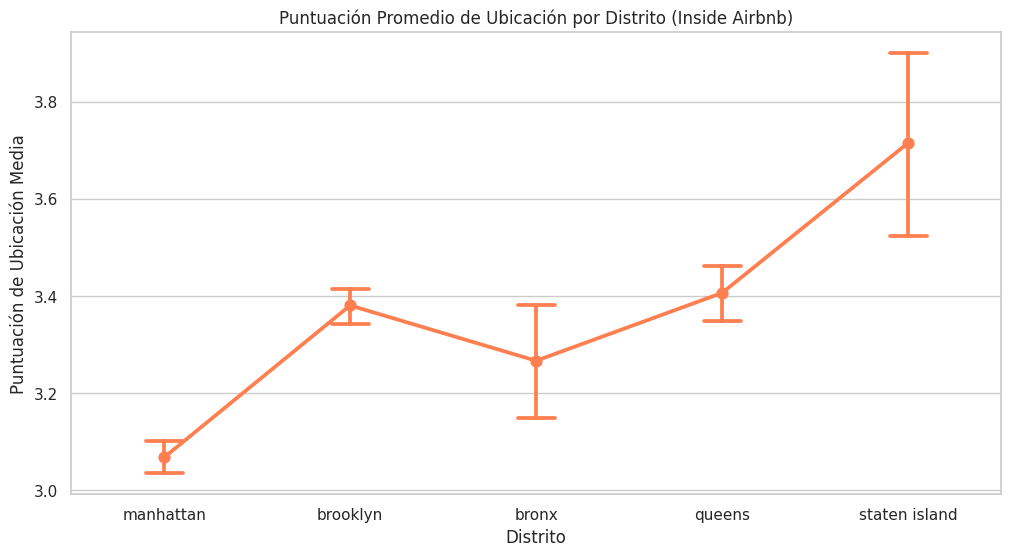

In [ ]:
plt.figure(figsize=(12, 6))
sns.pointplot(x='neighbourhood_group_cleansed', y='review_scores_location',
              data=df_insideairbnb_columnas_relevantes, capsize=.2, color='coral')

plt.title('Puntuación Promedio de Ubicación por Distrito (Inside Airbnb)')
plt.xlabel('Distrito')
plt.ylabel('Puntuación de Ubicación Media')
plt.show()

Este gráfico permite identificar qué distritos son percibidos como 'estratégicos' por los turistas. Manhattan lidera la puntuación de ubicación, validando que la densidad de puntos de interés urbanos en esta zona es la más alta y valorada de NYC.

### Puntuación de Ubicación vs. Calificación General

Este diagrama de dispersión permite observar la densidad y la tendencia entre la percepción de la zona y la satisfacción global.

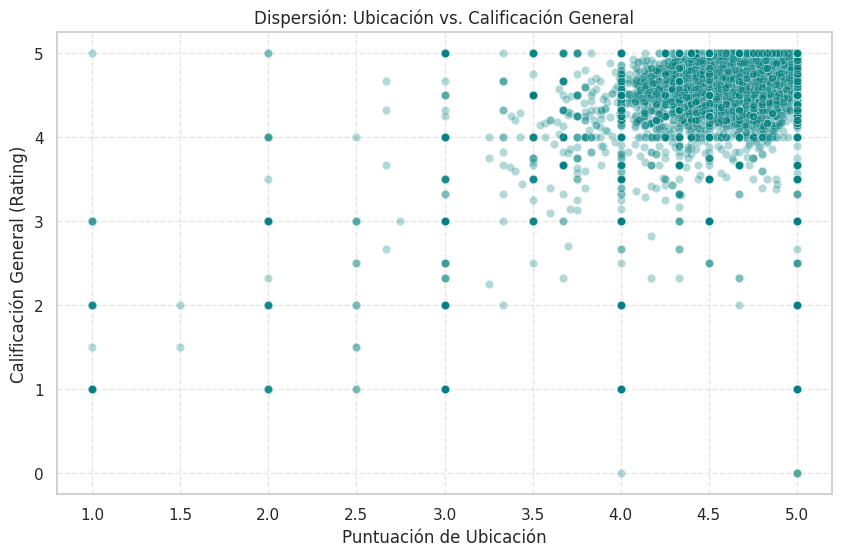

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar valores en 0 para evitar sesgos por falta de datos
df_filtered = df_insideairbnb_columnas_relevantes[df_insideairbnb_columnas_relevantes['review_scores_location'] > 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='review_scores_location', y='review_scores_rating',
                alpha=0.3, color='teal')

plt.title('Dispersión: Ubicación vs. Calificación General')
plt.xlabel('Puntuación de Ubicación')
plt.ylabel('Calificación General (Rating)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

La concentración de puntos en la esquina superior derecha indica que los alojamientos mejor ubicados (cerca de puntos de interés) son los que sistemáticamente reciben las mejores calificaciones, lo que valida la importancia estratégica de la ubicación para el negocio.